<a href="https://colab.research.google.com/github/edemile/ML-Final-project/blob/main/DS4400_Project_Random_Forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Random Forest Implementation
[Link to dataset](https://docs.google.com/spreadsheets/d/1K9R2xpxjPZYypVshY3fKUC5-VHWPgP0KxQivMES2zsQ/export?format=csv&gid=86751017)

In [12]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import roc_curve, confusion_matrix, ConfusionMatrixDisplay

In [3]:
# Import Google Drive to upload data
from google.colab import drive
drive.mount('/content/drive')

# Read in data from file path
file_id = '1K9R2xpxjPZYypVshY3fKUC5-VHWPgP0KxQivMES2zsQ'
file_path = f"https://docs.google.com/spreadsheets/d/{file_id}/export?format=csv&gid=86751017"

df = pd.read_csv(file_path)

Mounted at /content/drive


In [4]:
# Define feature columns
feature_cols = [
  'High blood pressure',
  'High cholesterol',
  'Taking medicine for high cholesterol',
  'Taking medicine to control high blood pressure'
]

# Separate features and target
X = df[feature_cols]
y = df['high_risk']

In [5]:
# Impute missing values using mean
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)

In [6]:
# Split dataset into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(
  X_imputed, y,
  test_size=0.2,
  random_state=42,
  stratify=y
)

# Standardize features
scaler = StandardScaler()

# Fit scaler on training data and transform both sets
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

Training set size: 599
Testing set size: 150


In [7]:
def compute_rf_metrics(y_true, y_pred, y_probs, dataset_name):
  """ Computes and prints random forest model metrics.

  Args:
    y_true (numpy.ndarray): True labels
    y_pred (numpy.ndarray): Predicted class labels
    y_probs (numpy.ndarray): Predicted probabilities for positive class
    dataset_name (str): Name of dataset (e.g., "Training", "Testing")

  Returns:
    tuple: (accuracy, f1, auc)
  """

  # Compute metrics
  accuracy = accuracy_score(y_true, y_pred)
  precision = precision_score(y_true, y_pred)
  recall = recall_score(y_true, y_pred)
  f1 = f1_score(y_true, y_pred)
  auc = roc_auc_score(y_true, y_probs)

  # Print metrics
  print(f"\n{dataset_name} Metrics")
  print(f"Accuracy: {accuracy:.4f}")
  print(f"Precision: {precision:.4f}")
  print(f"Recall: {recall:.4f}")
  print(f"F1 Score: {f1:.4f}")
  print(f"ROC-AUC: {auc:.4f}")

  return accuracy, f1, auc

In [8]:
# Define hyperparameter grid
param_grid = {
  "n_estimators": [50, 100, 200, 500],  # Number of trees
  "max_depth": [None, 5, 10, 20]        # Tree depth (pruning)
}

# Create base Random Forest model
rf = RandomForestClassifier(random_state=42)

# Perform Grid Search with 5-fold cross-validation
grid_search = GridSearchCV(
  estimator=rf,
  param_grid=param_grid,
  cv=5,          # 5-fold CV
  scoring="f1",  # Optimize F1 score
  n_jobs=-1      # Use all CPUs
)

# Fit on training data
grid_search.fit(X_train, y_train)

# Print best parameters
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'max_depth': 10, 'n_estimators': 100}


In [9]:
# Get best model from grid search
best_rf = grid_search.best_estimator_

# Report CV performance
rf_cv_mean = grid_search.cv_results_['mean_test_score'][grid_search.best_index_]
rf_cv_std = grid_search.cv_results_['std_test_score'][grid_search.best_index_]

print(f"Mean CV F1: {rf_cv_mean:.4f} (+/- {rf_cv_std:.4f})")

# Make predictions
y_train_pred = best_rf.predict(X_train)
y_test_pred = best_rf.predict(X_test)

# Get probabilities for ROC-AUC
y_train_probs = best_rf.predict_proba(X_train)[:, 1]
y_test_probs = best_rf.predict_proba(X_test)[:, 1]

# Compute metrics for training set
compute_rf_metrics(y_train, y_train_pred, y_train_probs, "Training")

# Compute metrics for testing set
compute_rf_metrics(y_test, y_test_pred, y_test_probs, "Testing")

Mean CV F1: 0.8168 (+/- 0.0120)

Training Metrics
Accuracy: 0.9933
Precision: 0.9910
Recall: 0.9970
F1 Score: 0.9940
ROC-AUC: 0.9991

Testing Metrics
Accuracy: 0.8067
Precision: 0.7935
Recall: 0.8795
F1 Score: 0.8343
ROC-AUC: 0.8560


(0.8066666666666666, 0.8342857142857143, np.float64(0.8559611580650962))

<Figure size 640x480 with 0 Axes>

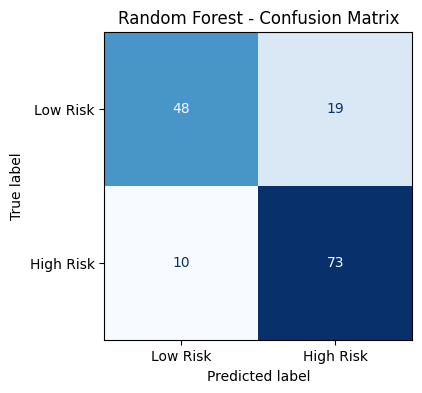

In [13]:
# Compute confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

# Show plot
plt.figure()
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low Risk', 'High Risk'])
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
plt.title("Random Forest - Confusion Matrix")
plt.show()

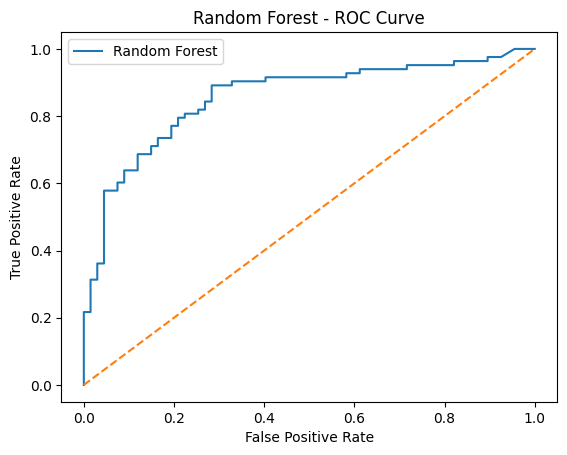

In [10]:
# Compute ROC curve values
fpr, tpr, _ = roc_curve(y_test, y_test_probs)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, label="Random Forest")
plt.plot([0, 1], [0, 1], linestyle="--")

# Labels and title
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest - ROC Curve")
plt.legend()

# Show plot
plt.show()


Feature Importance Rankings:
                                          Feature  Importance
0                             High blood pressure    0.491287
1                                High cholesterol    0.184914
3  Taking medicine to control high blood pressure    0.163096
2            Taking medicine for high cholesterol    0.160703


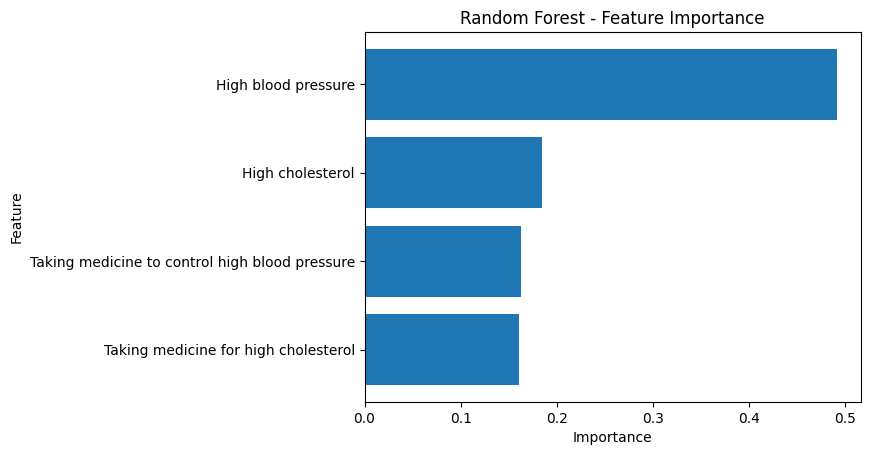

In [11]:
# Get feature importance scores
importances = best_rf.feature_importances_

# Convert to DataFrame
importance_df = pd.DataFrame({
  "Feature": feature_cols,
  "Importance": importances
})

# Sort by importance
importance_df = importance_df.sort_values(by="Importance", ascending=False)

# Print rankings
print("\nFeature Importance Rankings:")
print(importance_df)

# Plot feature importance
plt.figure()
plt.barh(importance_df["Feature"], importance_df["Importance"])

# Put most important at top
plt.gca().invert_yaxis()

# Plot feature importance
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest - Feature Importance")

# Show plot
plt.show()